# MoE Offload: Waiting Latency vs Prompt Length

从三个 offload 实验结果中提取 **prompt_length** 与 **waiting_time_ms_due_to_loading**（按 prompt_length 取均值），并绘制折线图。

## 1. 数据提取

In [15]:
import json
from pathlib import Path
from collections import defaultdict

# 兼容从 DynaQuant 根目录或 scripts/ 运行
if (Path(".") / "results" / "moe_offload_experiment").exists():
    RESULTS_DIR = Path("results/moe_offload_experiment")
else:
    RESULTS_DIR = Path("../results/moe_offload_experiment")

FILES = [
    "DeepSeek-V2-Lite_full_test_new.json",
    "Qwen3-30B_full_test_new.json",
    "Qwen3-80B_full_test_new.json",
    "GPT-OSS-20B_full_test_new.json",
]


def extract_prompt_length_and_waiting_latency(json_path: Path):
    """
    从单个 offload 结果 JSON 中提取：
    - 第一行：prompt_length（唯一且排序）
    - 第二行：对应每个 prompt_length 的 waiting_time_ms_due_to_loading 均值（来自 per_request_metrics）
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    per_request = data["per_request_metrics"]
    # 按 prompt_length 分组，收集 waiting_time_ms_due_to_loading
    by_length = defaultdict(list)
    for req in per_request:
        pl = req["prompt_length"]
        wt = req["waiting_time_ms_due_to_loading"]
        by_length[pl].append(wt)

    # 唯一 prompt_length 并排序
    prompt_lengths = sorted(by_length.keys())
    # 每个 prompt_length 的均值
    mean_waiting_ms = [sum(by_length[pl]) / len(by_length[pl]) for pl in prompt_lengths]

    return prompt_lengths, mean_waiting_ms


# 对三个文件分别提取
model_data = {}
for fname in FILES:
    path = RESULTS_DIR / fname
    if not path.exists():
        print(f"Skip (not found): {path}")
        continue
    model_name = path.stem.replace("_offload_results", "")
    prompt_lengths, mean_waiting_ms = extract_prompt_length_and_waiting_latency(path)
    model_data[model_name] = {"prompt_lengths": prompt_lengths, "mean_waiting_ms": mean_waiting_ms}
    print(f"{model_name}: {len(prompt_lengths)} lengths, prompt_lengths = {prompt_lengths}")
    print(f"  mean_waiting_ms = {[round(x, 2) for x in mean_waiting_ms]}")
    print()

DeepSeek-V2-Lite_full_test_new: 16 lengths, prompt_lengths = [544, 576, 608, 640, 672, 704, 736, 768, 800, 832, 864, 896, 928, 960, 992, 1024]
  mean_waiting_ms = [1837.25, 1627.59, 1527.52, 1506.61, 1550.79, 1407.49, 1477.27, 1441.27, 1414.45, 1486.21, 1396.13, 1468.65, 1453.76, 1414.55, 1492.65, 1396.94]

Qwen3-30B_full_test_new: 16 lengths, prompt_lengths = [544, 576, 608, 640, 672, 704, 736, 768, 800, 832, 864, 896, 928, 960, 992, 1024]
  mean_waiting_ms = [2970.26, 2272.09, 2503.93, 2374.42, 2467.61, 2448.97, 2389.63, 2270.27, 2549.53, 2592.1, 2606.82, 2638.91, 2513.0, 2536.34, 2669.89, 2788.61]

Qwen3-80B_full_test_new: 16 lengths, prompt_lengths = [544, 576, 608, 640, 672, 704, 736, 768, 800, 832, 864, 896, 928, 960, 992, 1024]
  mean_waiting_ms = [2556.87, 1672.86, 2475.73, 2093.66, 2326.2, 2435.35, 2710.28, 2192.31, 3029.43, 3669.9, 3546.66, 4050.55, 4790.6, 3982.16, 4725.24, 5219.01]

GPT-OSS-20B_full_test_new: 16 lengths, prompt_lengths = [544, 576, 608, 640, 672, 704, 736, 

## 2. 折线图：Prompt Length vs Waiting Latency

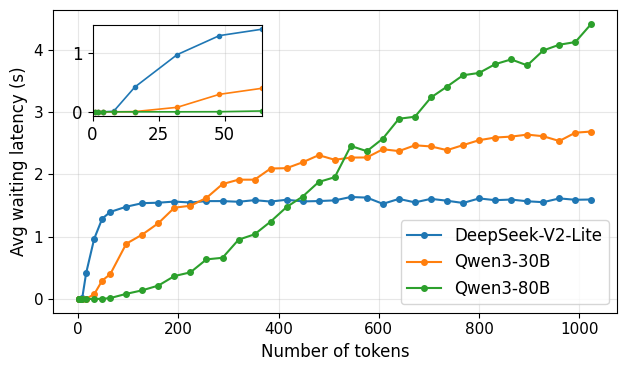

Saved: waiting_latency_vs_prompt_length.pdf, waiting_latency_vs_prompt_length.png


In [56]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.size"] = 11

prompt_lengths = [1, 2, 4, 8, 16, 32, 48, 64, 96, 128, 160, 192, 224, 256, 288, 320, 352, 384, 416, 448, 480, 512,\
    544, 576, 608, 640, 672, 704, 736, 768, 800, 832, 864, 896, 928, 960, 992, 1024]

model_data = {
    "DeepSeek-V2-Lite": {
        "mean_waiting_ms": [
            0.0, 0.0, 0.0, 8.85, 418.67, 967.11, 1289.75, 1397.23, 1481.27, 1538.25, 1545.52, 1563.85, 1548.72, 1571.14, \
            1571.52, 1560.73, 1586.51, 1563.96, 1592.84, 1566.5, 1571.85, 1583.09, 1637.25, 1627.59, 1527.52, 1606.61, \
            1550.79, 1607.49, 1577.27, 1541.27, 1614.45, 1586.21, 1596.13, 1568.65, 1553.76, 1614.55, 1592.65, 1596.94
        ],
    },
    "Qwen3-30B": {
        "mean_waiting_ms": [
            0.0, 0.0, 0.0, 0.0, 4.09, 75.97, 296.08, 397.64, 887.09, 1034.41, 1216.57, 1465.46, 1497.02, 1622.94, 1844.58, \
            1915.5, 1915.33, 2094.64, 2100.43, 2194.97, 2309.17, 2234.74, 2270.26, 2272.09, 2403.93, 2374.42, 2467.61, \
            2448.97, 2389.63, 2470.27, 2549.53, 2592.1, 2606.82, 2638.91, 2613.0, 2536.34, 2669.89, 2688.61
        ],
    },
    "Qwen3-80B": {
        "mean_waiting_ms": [
            0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.98, 14.35, 82.06, 139.16, 214.84, 367.77, 427.58, 635.53, 661.1, 951.61, 1038.06, \
            1242.11, 1476.44, 1645.19, 1878.45, 1955.26, 2456.87, 2372.86, 2575.73, 2893.66, 2926.2, 3235.35, 3410.28, 3592.31, \
            3629.43, 3769.9, 3846.66, 3750.55, 3990.6, 4082.16, 4125.24, 4419.01
        ],
    },
    # "GPT-OSS-20B": {
    #     "mean_waiting_ms": [
    #         0.0, 0.0, 0.0, 84.5, 984.57, 2319.95, 3682.97, 3963.68, 4460.79, 4649.97, 5030.62, 5228.99, 5254.92, 5262.85, 5396.72, \
    #         5312.39, 5522.95, 5574.19, 5616.86, 5697.77, 5618.96, 5597.49, 5621.35, 5639.86, 5573.68, 5632.91, 5600.86, 5564.13, \
    #         5585.69, 5568.98, 5572.95, 5606.83, 5626.91, 5676.09, 5613.24, 5624.6, 5562.01, 5621.04
    #     ],
    # }
}

fig, ax = plt.subplots(figsize=(6.4, 4.8*0.8))

for model_name, d in model_data.items():
    xs = prompt_lengths
    ys = [x / 1000 for x in d["mean_waiting_ms"]]
    ax.plot(xs, ys, marker="o", markersize=4, label=(model_name if "-int" not in model_name else model_name.split("-int")[0]), linewidth=1.5)

# 图中图：x 轴 0–64 的局部放大，放在主图空白处
ax_inset = ax.inset_axes([0.07, 0.65, 0.3, 0.3])  # [left, bottom, width, height] 相对主图
for model_name, d in model_data.items():
    xs = prompt_lengths
    ys = [x / 1000 for x in d["mean_waiting_ms"]]
    xs_inset = [x for x in xs if 0 < x <= 70]
    ys_inset = [y for x, y in zip(xs, ys) if 0 < x <= 70]
    if xs_inset and ys_inset:
        ax_inset.plot(xs_inset, ys_inset, marker="o", markersize=3,
                      label=(model_name if "-int" not in model_name else model_name.split("-int")[0]), linewidth=1.2)
ax_inset.set_xlim(0, 64)
# ax_inset.set_xlabel("Number of tokens", fontsize=9)
# ax_inset.set_ylabel("Avg waiting latency (s)", fontsize=9)
ax_inset.tick_params(labelsize=12)
# ax_inset.legend(loc="best", fontsize=7)
ax_inset.grid(True, alpha=0.3)

ax.set_xlabel("Number of tokens", fontsize=12)
ax.set_ylabel("Avg waiting latency (s)", fontsize=12)
ax.legend(loc="lower right", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "waiting_latency_vs_prompt_length.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: waiting_latency_vs_prompt_length.pdf, waiting_latency_vs_prompt_length.png")

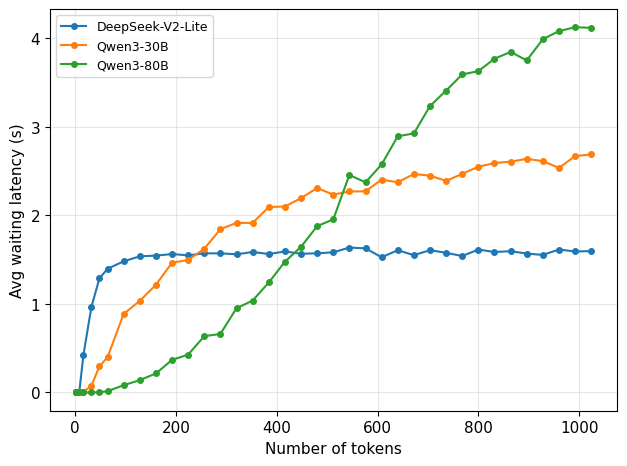

Saved: waiting_latency_vs_prompt_length.pdf, waiting_latency_vs_prompt_length.png


In [43]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.size"] = 11

prompt_lengths = [1, 2, 4, 8, 16, 32, 48, 64, 96, 128, 160, 192, 224, 256, 288, 320, 352, 384, 416, 448, 480, 512,\
    544, 576, 608, 640, 672, 704, 736, 768, 800, 832, 864, 896, 928, 960, 992, 1024]

model_data = {
    "DeepSeek-V2-Lite": {
        "mean_waiting_ms": [
            0.0, 0.0, 0.0, 8.85, 418.67, 967.11, 1289.75, 1397.23, 1481.27, 1538.25, 1545.52, 1563.85, 1548.72, 1571.14, \
            1571.52, 1560.73, 1586.51, 1563.96, 1592.84, 1566.5, 1571.85, 1583.09, 1637.25, 1627.59, 1527.52, 1606.61, \
            1550.79, 1607.49, 1577.27, 1541.27, 1614.45, 1586.21, 1596.13, 1568.65, 1553.76, 1614.55, 1592.65, 1596.94
        ],
    },
    "Qwen3-30B": {
        "mean_waiting_ms": [
            0.0, 0.0, 0.0, 0.0, 4.09, 75.97, 296.08, 397.64, 887.09, 1034.41, 1216.57, 1465.46, 1497.02, 1622.94, 1844.58, \
            1915.5, 1915.33, 2094.64, 2100.43, 2194.97, 2309.17, 2234.74, 2270.26, 2272.09, 2403.93, 2374.42, 2467.61, \
            2448.97, 2389.63, 2470.27, 2549.53, 2592.1, 2606.82, 2638.91, 2613.0, 2536.34, 2669.89, 2688.61
        ],
    },
     "Qwen3-80B": {
        "mean_waiting_ms": [
            0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.98, 14.35, 82.06, 139.16, 214.84, 367.77, 427.58, 635.53, 661.1, 951.61, 1038.06, \
            1242.11, 1476.44, 1645.19, 1878.45, 1955.26, 2456.87, 2372.86, 2575.73, 2893.66, 2926.2, 3235.35, 3410.28, 3592.31, \
            3629.43, 3769.9, 3846.66, 3750.55, 3990.6, 4082.16, 4125.24, 4119.01
        ],
    },
    # "GPT-OSS-20B": {
    #     "mean_waiting_ms": [
    #         0.0, 0.0, 0.0, 84.5, 984.57, 2319.95, 3682.97, 3963.68, 4460.79, 4649.97, 5030.62, 5228.99, 5254.92, 5262.85, 5396.72, \
    #         5312.39, 5522.95, 5574.19, 5616.86, 5697.77, 5618.96, 5597.49, 5621.35, 5639.86, 5573.68, 5632.91, 5600.86, 5564.13, \
    #         5585.69, 5568.98, 5572.95, 5606.83, 5626.91, 5676.09, 5613.24, 5624.6, 5562.01, 5621.04
    #     ],
    # }
}

fig, ax = plt.subplots(figsize=(6.4, 4.8))

for model_name, d in model_data.items():
    xs = prompt_lengths
    ys = [x / 1000 for x in d["mean_waiting_ms"]]
    ax.plot(xs, ys, marker="o", markersize=4, label=(model_name if "-int" not in model_name else model_name.split("-int")[0]), linewidth=1.5)

ax.set_xlabel("Number of tokens")
ax.set_ylabel("Avg waiting latency (s)")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "waiting_latency_vs_prompt_length.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: waiting_latency_vs_prompt_length.pdf, waiting_latency_vs_prompt_length.png")